<a href="https://colab.research.google.com/github/JaySharma424/Deep-Learning/blob/main/EfficientNetB0_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## G-Drive Mount

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Libraries

In [ ]:
from tensorflow.keras.applications.efficientnet import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [ ]:
import tensorflow as tf
import tensorflow
import os
# from tensorflow.keras.layers.experimental import preprocessing
from tensorflow import keras
from tensorflow.keras import layers,Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Attention
# from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, accuracy_score
import matplotlib.pyplot as plt

# from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2S, preprocess_input
from tensorflow.keras import callbacks
from google.colab.patches import cv2_imshow
import pandas as pd
import numpy as np
import seaborn as sns
# import imutils
import time
import cv2
# from cuml import SVC # for python 3.11
from sklearn.svm import SVC

## Configuration

In [ ]:
# =========================================================
# CONFIG - Updated with working paths
# =========================================================
MASTER_DIR = 'EfficientNetB0'
MASTER_PATH = f'/content/drive/MyDrive/{MASTER_DIR}/'
os.makedirs(MASTER_PATH, exist_ok=True)

TRAIN_CSV = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/train_1.csv"
VALID_CSV = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/valid.csv"
TEST_CSV = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/test.csv"

TRAIN_DIR = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/train_images/train_images/"
VALID_DIR = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/val_images/val_images/"
TEST_DIR = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/test_images/test_images/"

CHECKPOINT_DIR = f"/content/drive/MyDrive/{MASTER_DIR}/checkpoint/"
CSV_LOG = f"/content/drive/MyDrive/{MASTER_DIR}/training.csv"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-4
NUM_CLASSES = 5

In [ ]:
print(os.listdir(TRAIN_DIR))
print(os.listdir(VALID_DIR))
print(os.listdir(TEST_DIR))

['a0d04a19cf40.png', 'a14bbd9a583e.png', 'a01c590c444f.png', 'a1b28bcbce00.png', 'a19507501b40.png', 'a15590a7d774.png', 'a21b37719f9b.png', 'a28bfb772f50.png', 'a2163f0c2af5.png', 'a2811f512c1c.png', 'a19ecd0a706e.png', 'a182b5b191de.png', 'a1822dd8d05d.png', 'a150ff5dfe07.png', 'a1faeb4d5f10.png', 'a188c60b93fb.png', 'a1b12fdce6c3.png', 'a1872f9c0cba.png', 'a15652b22ab8.png', 'a2696f444ecb.png', 'a1e236fbc863.png', 'a1edf0e66592.png', 'a1eb88562239.png', 'a247961a5cd9.png', 'a26f50218b84.png', 'a15470303941.png', 'a3fcf42ff56d.png', 'a4012932e18d.png', 'a3132c8828e4.png', 'a419fcb2dfb5.png', 'a3475dc3ac80.png', 'a3b2e93d058b.png', 'a32b5ce3d48a.png', 'a3706ce27869.png', 'a2d349f567a6.png', 'a3ad6c2db6f1.png', 'a3802934bad7.png', 'a32886cb31ab.png', 'a34fc5376669.png', 'a2b995b81692.png', 'a3d2a0c4cd17.png', 'a2ad3da4c7d6.png', 'a2b97d98f130.png', 'a386ec9aabde.png', 'a2ddabee14e9.png', 'a30a143a53a3.png', 'a3bd2e034614.png', 'a384e688e228.png', 'a3957df90a78.png', 'a2dff8dbc9f8.png',

## Data loading

In [ ]:
def load_data():
    train = pd.read_csv(TRAIN_CSV, encoding='utf-8')
    test = pd.read_csv(TEST_CSV, encoding='utf-8')
    valid = pd.read_csv(VALID_CSV, encoding='utf-8')

    train_dir = TRAIN_DIR
    test_dir = TEST_DIR
    valid_dir = VALID_DIR

    # construct file paths directly within function:
    train['image_path'] = train_dir + train['id_code'] + '.png'
    test['image_path'] = test_dir + test['id_code'] + '.png'
    valid['image_path'] = valid_dir + valid['id_code'] + '.png'

    train['train_images'] = train['id_code'] + '.png'
    test['test_images'] = test['id_code'] + '.png'
    valid['valid_images'] = valid['id_code'] + '.png'

    train['diagnosis'] = train['diagnosis'].astype(str)
    test['diagnosis'] = test['diagnosis'].astype(str)
    valid['diagnosis'] = valid['diagnosis'].astype(str)

    return train, test, valid

### Image Augmentation

In [ ]:
img_augmentation = Sequential(
    [
        tf.keras.layers.RandomRotation(factor=(-0.15, 0.15)),
        tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
        tf.keras.layers.RandomFlip(),
        tf.keras.layers.RandomContrast(factor=0.6),
    ],
    name="img_augmentation",
)

## Model Definition

In [ ]:
def build_EfficientNetB0_model(num_classes):
    IMG_SIZE = (224, 224, 3)
    # Load the EfficientNetV2S base model without the top (classification) layer
    base_model = EfficientNetB0(input_shape=IMG_SIZE, include_top=False, weights='imagenet')

    # Freeze the base model layers
    base_model.trainable = False
    unfrozen_count = 0
    unfreeze_top_layers = 10  # Unfreeze the top 10 layers
    for layer in reversed(base_model.layers):
        if unfrozen_count >= unfreeze_top_layers:
            break
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True
            unfrozen_count += 1

    # Create a new model on top of the base model
    inputs = keras.Input(shape=IMG_SIZE)
    x = img_augmentation(inputs)
    x = preprocess_input(x) # EfficientNetB3 expects inputs in the [-1, 1] range after preprocessing
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    # adding conv layers
    # x = layers.Conv2D(32, (3, 3), activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    # outputs = layers.Dense(5, activation='softmax')(x)
    model = keras.Model(inputs, outputs)

    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [ ]:
build_EfficientNetB0_model(NUM_CLASSES).summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ img_augmentation (Sequential)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,061,096 (15.49 MB)

 Trainable params: 909,365 (3.47 MB)

 Non-trainable params: 3,151,731 (12.02 MB)

### Callbacks

In [ ]:
from tensorflow.keras.callbacks import CSVLogger
csv_logger = CSVLogger(CSV_LOG, append=True, separator=',')

cbs = [
        callbacks.ModelCheckpoint('/content/drive/MyDrive/EffnetB3SVM/best_model.keras', save_best_only=True, monitor='val_accuracy',verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-4,verbose=1),
        callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True,verbose=1),
        csv_logger
    ]

## Main

In [ ]:
train_df, test_df, valid_df = load_data()

In [ ]:
if __name__ == "__main__":
    train_df, test_df, valid_df = load_data()

    train_batches = ImageDataGenerator().flow_from_dataframe(
    dataframe=train_df, x_col='image_path', y_col='diagnosis', target_size=(224,224), batch_size=BATCH_SIZE)

    valid_batches = ImageDataGenerator().flow_from_dataframe(
    dataframe=valid_df, x_col='image_path', y_col='diagnosis', target_size=(224,224), batch_size=BATCH_SIZE)

    model = build_EfficientNetB0_model(NUM_CLASSES)

    history = model.fit(train_batches, epochs=EPOCHS, validation_data=valid_batches, verbose=1,callbacks=cbs)

Found 2930 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 25s/step - accuracy: 0.4958 - loss: 1.4656 
Epoch 1: val_accuracy improved from None to 0.71311, saving model to /content/drive/MyDrive/EffnetB3SVM/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/EffnetB3SVM/best_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 2618s 28s/step - accuracy: 0.5939 - loss: 1.1639 - val_accuracy: 0.7131 - val_loss: 0.9703 - learning_rate: 1.0000e-04
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7118 - loss: 0.8010
Epoch 2: val_accuracy did not improve from 0.71311
92/92 ━━━━━━━━━━━━━━━━━━━━ 418s 5s/step - accuracy: 0.7119 - loss: 0.7903 - val_accuracy: 0.7077 - val_loss: 0.8648 - learning_rate: 1.0000e-04
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7460 - loss: 0.7008
Epoch 3: val_accuracy improv

In [ ]:
test_batches = ImageDataGenerator().flow_from_dataframe(
    dataframe=test_df, x_col='image_path', y_col='diagnosis', target_size=(224,224), batch_size=BATCH_SIZE)

Found 366 validated image filenames belonging to 5 classes.


load model


In [ ]:
# load model
model = tf.keras.models.load_model('/content/drive/MyDrive/EffnetB3SVM/best_model.keras')

In [ ]:
eval_report = model.evaluate(test_batches)
print(f"Test Loss: {eval_report[0]}, Test Accuracy: {eval_report[1]}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 342s 30s/step - accuracy: 0.7486 - loss: 0.7549
Test Loss: 0.7549030184745789, Test Accuracy: 0.748633861541748


In [ ]:
# Re-initialize test_batches before predicting to ensure it's not exhausted
test_batches = ImageDataGenerator().flow_from_dataframe(
    dataframe=test_df, x_col='image_path', y_col='diagnosis', target_size=(224,224), batch_size=BATCH_SIZE, shuffle=False
)

# classification report
y_pred = model.predict(test_batches)
y_pred = np.argmax(y_pred, axis=1)
print(classification_report(test_batches.labels, y_pred))

Found 366 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.
12/12 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       199
           1       0.34      0.37      0.35        30
           2       0.57      0.94      0.71        87
           3       0.00      0.00      0.00        17
           4       0.22      0.06      0.10        33

    accuracy                           0.75       366
   macro avg       0.42      0.45      0.42       366
weighted avg       0.72      0.75      0.72       366

              precision    recall  f1-score   support

           0       0.98      0.90      0.94       199
           1       0.34      0.37      0.35        30
           2       0.57      0.94      0.71        87
           3       0.00      0.00      0.00        17
           4       0.22      0.06      0.1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [ ]:
# save classification report
report = classification_report(test_batches.labels, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv('/content/drive/MyDrive/EffnetB0SVM/effnetb0_classification_report.csv')

In [ ]:
log = pd.read_csv('/content/drive/MyDrive/EffnetB0SVM/training.csv')
log.head()

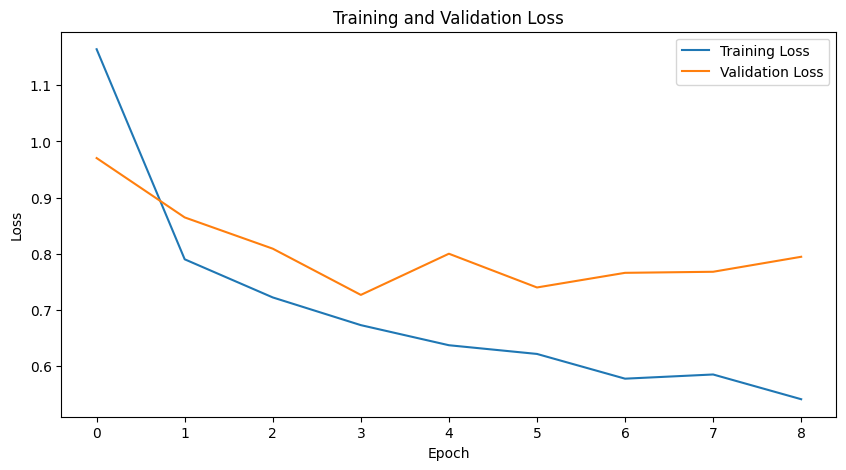

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.savefig('/content/drive/MyDrive/EffnetB0SVM/training_validation_loss.png')
plt.show()

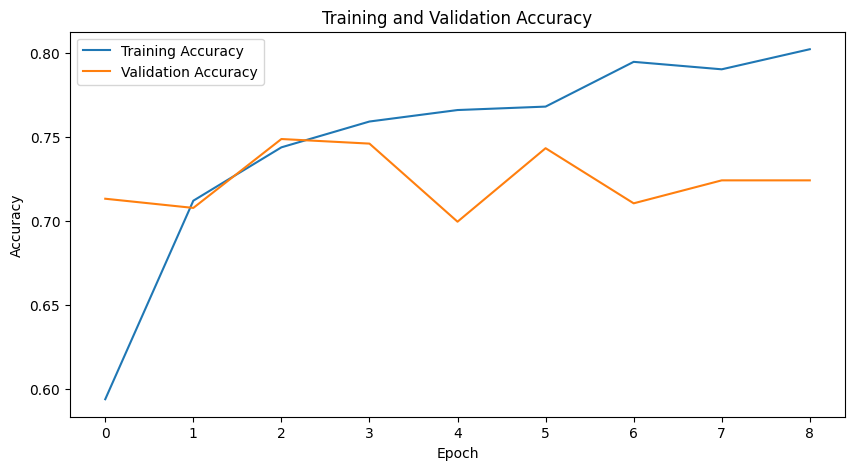

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.savefig('/content/drive/MyDrive/EffnetB0SVM/training_validation_accuracy.png')
plt.show()

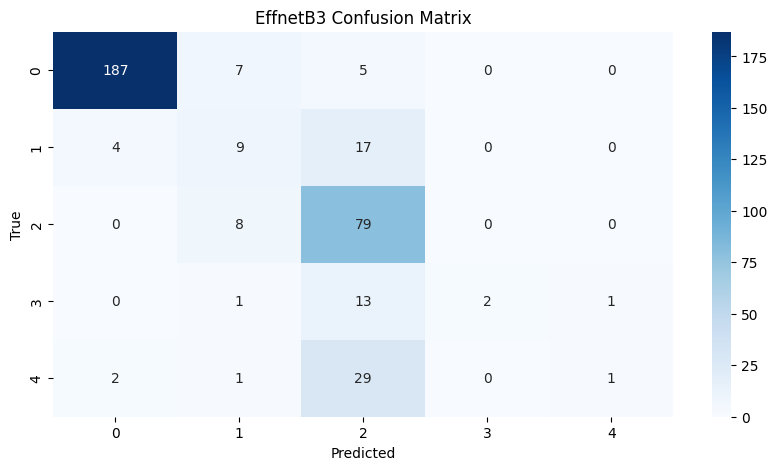

In [ ]:
# heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(confusion_matrix(test_batches.labels, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('EffnetB3 Confusion Matrix')
plt.savefig('/content/drive/MyDrive/EffnetB0SVM/effnetb3_confusion_matrix.png')
plt.show()

# DataFrame

In [ ]:
train_df, test_df, valid_df = load_data()

train_batches = ImageDataGenerator().flow_from_dataframe(dataframe=train_df, x_col='image_path', y_col='diagnosis', target_size=(224,224), batch_size=BATCH_SIZE)

valid_batches = ImageDataGenerator().flow_from_dataframe(dataframe=valid_df, x_col='image_path', y_col='diagnosis', target_size=(224,224), batch_size=BATCH_SIZE)

test_batches = ImageDataGenerator().flow_from_dataframe(dataframe=test_df, x_col='image_path', y_col='diagnosis', target_size=(224,224), batch_size=BATCH_SIZE, shuffle=False)

Found 2930 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.


# SVM

In [ ]:
X_train, y_train = [], []
for _ in range(len(train_batches)):
    images, labels = next(train_batches)
    X_train.append(images)
    y_train.append(labels)

In [ ]:
X_train[0].shape

In [ ]:
# Convert lists to arrays
X_train = np.vstack(X_train)
y_train = np.vstack(y_train)

In [ ]:
X_train.shape

In [ ]:
y_train.shape

In [ ]:
# Reshape X_train to be 2D (necessary for SVM)
X_train1 = X_train.reshape(X_train.shape[0], -1)

In [ ]:
X_train1.shape

In [ ]:
y_train.shape

In [ ]:
# test_batches.reset()

In [ ]:
import tqdm

In [ ]:
from tqdm import tqdm

In [ ]:
# Collect data from the generator
X_test, y_test = [], []
for _ in tqdm(range(len(test_batches))):
    images, labels = next(test_batches)
    X_test.append(images)
    y_test.append(labels)

100%|██████████| 12/12 [00:41<00:00,  3.44s/it]


In [ ]:
# Convert lists to arrays
X_test = np.vstack(X_test)
y_test = np.vstack(y_test)

In [ ]:
X_test.shape

In [ ]:
# Reshape X_train to be 2D (necessary for SVM)
X_test1 = X_test.reshape(X_test.shape[0], -1)

In [ ]:
X_test1.shape

In [ ]:
# feature_extractor_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer('global_average_pooling2d').output)

# features_array_train = feature_extractor_model.predict(X_train_data)
# features_array_test = feature_extractor_model.predict(X_test_data)

# Convert one-hot encoded labels to integer labels for SVC
y_train_labels = np.argmax(y_train_onehot, axis=1)
y_test_labels = np.argmax(y_test_onehot, axis=1)

# print(f"Shape of extracted training features: {features_array_train.shape}")
# print(f"Shape of extracted test features: {features_array_test.shape}")
print(f"Shape of training labels for SVM: {y_train_labels.shape}")
print(f"Shape of test labels for SVM: {y_test_labels.shape}")

NameError: name 'y_train_onehot' is not defined

In [ ]:
from tensorflow.python.keras.models import Model
model1 = tf.keras.Model(inputs = model.input, outputs=model.layers[-3].output)

features_array_train1 = model1.predict(X_train)
# features_array_train1_reshape = features_array_train1.reshape(features_array_train1.shape[0], -1)

92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 102ms/step


In [ ]:
model1.save('/content/drive/MyDrive/EffnetB0SVM/feature_extractor_model.keras')

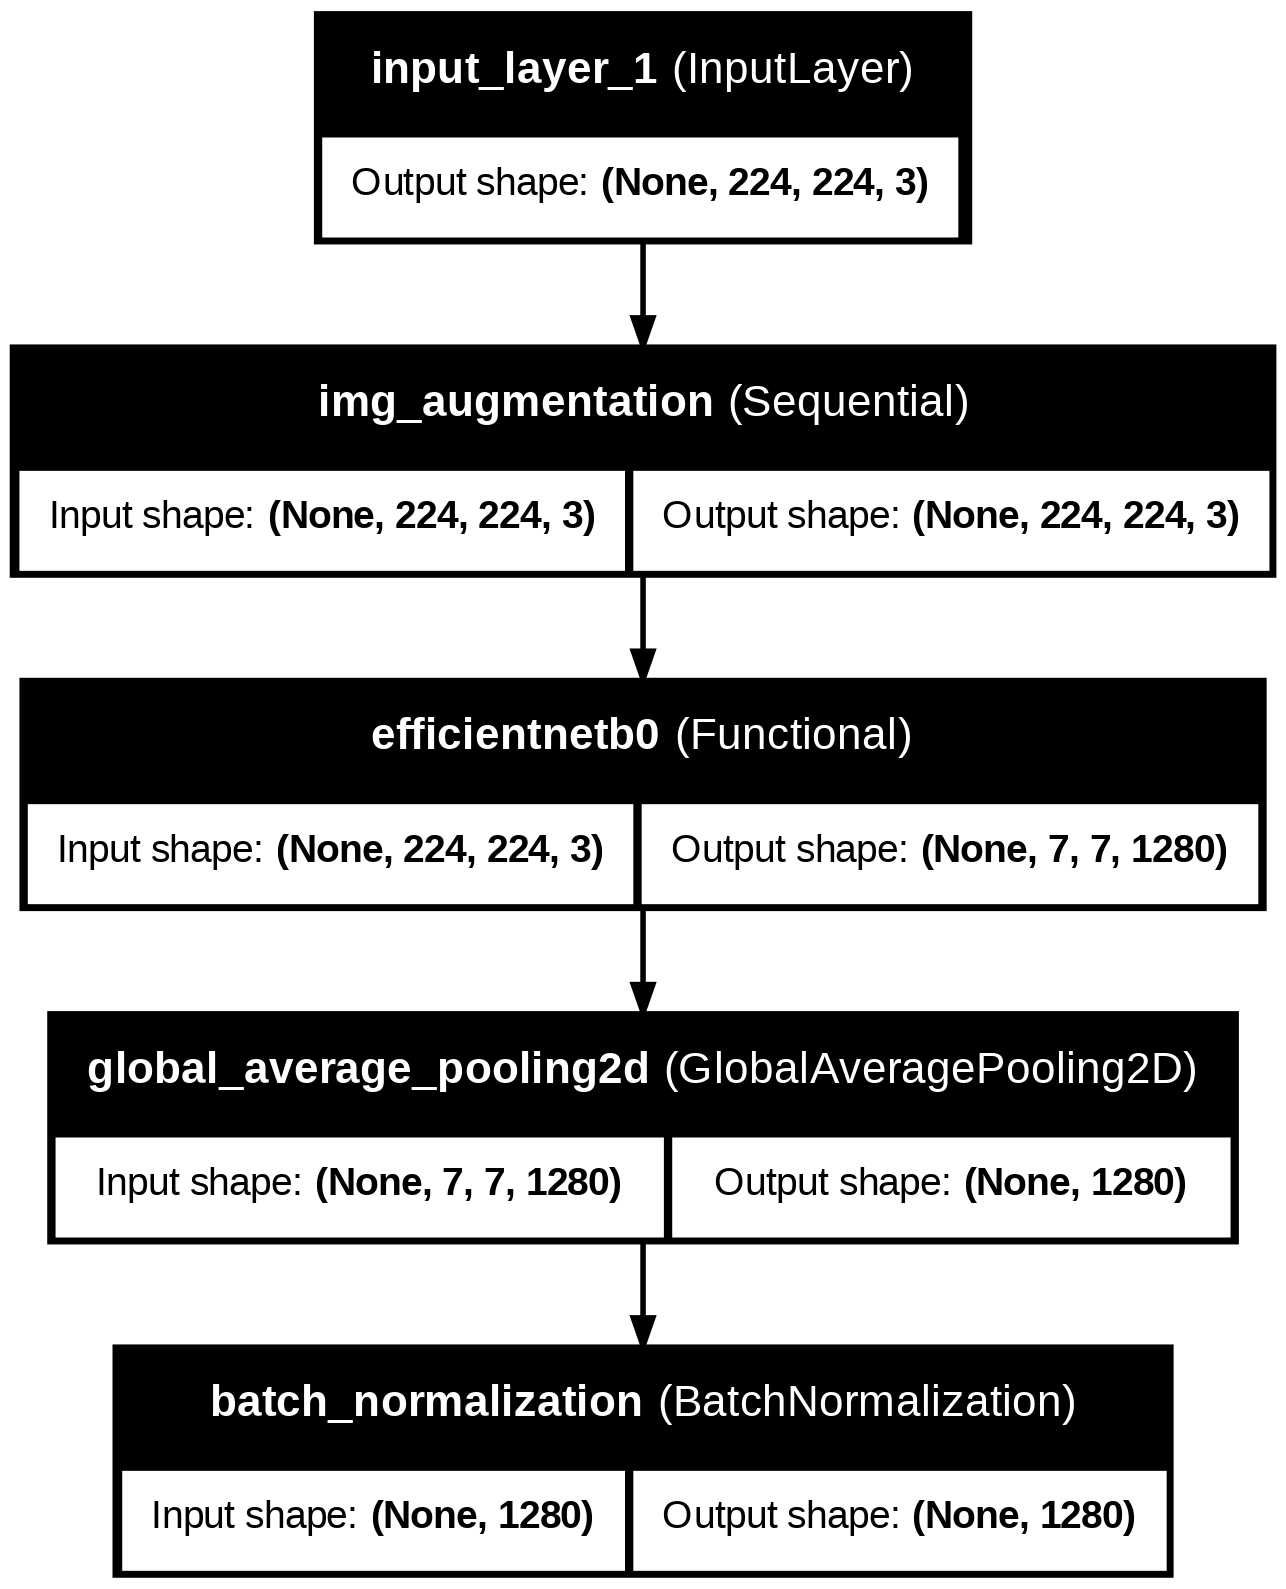

In [ ]:
# save model1 architecture as picture
tf.keras.utils.plot_model(model1, to_file='/content/drive/MyDrive/EffnetB0SVM/feature_extractor_architecture.png', show_shapes=True, show_layer_names=True)

In [ ]:
features_array_train1.shape

(2930, 1280)

In [ ]:
features_array_train1_reshape = features_array_train1.reshape(features_array_train1.shape[0], -1)
print(features_array_train1_reshape.shape)


(2930, 1280)


In [ ]:
features_array_test1 = model1.predict(X_test)
features_array_test1_reshape = features_array_test1.reshape(features_array_test1.shape[0], -1)
X_test1 = X_test.reshape(X_test.shape[0], -1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step


In [ ]:
model1.save('/content/drive/MyDrive/EffnetB0SVM/svm_model.keras')

In [ ]:
from sklearn.svm import SVC
svm_clf = SVC(verbose=True, kernel='rbf')
svm_clf.fit(features_array_train1_reshape, y_train.argmax(axis=1))

[LibSVM]

SVC(verbose=True)

In [ ]:
pred_1 = svm_clf.predict(features_array_test1_reshape)

In [ ]:
print(accuracy_score(y_test.argmax(axis=1), pred_1))

0.8360655737704918


Now that the SVM is trained, we can evaluate its performance on the test set.

In [ ]:
print(classification_report(y_test.argmax(axis=1), pred_1))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       199
           1       0.64      0.47      0.54        30
           2       0.65      0.97      0.77        87
           3       0.67      0.24      0.35        17
           4       1.00      0.27      0.43        33

    accuracy                           0.84       366
   macro avg       0.79      0.58      0.61       366
weighted avg       0.86      0.84      0.82       366



In [ ]:
# save svm classification report
report = classification_report(y_test.argmax(axis=1), pred_1, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv('/content/drive/MyDrive/EffnetB0SVM/svm_classification_report.csv')

In [ ]:
import pickle
with open('/content/drive/MyDrive/EffnetB0SVM/svm_model.pkl', 'wb') as file:
    pickle.dump(svm_clf, file)

### Hyperparameter Tuning for SVM

Hyperparameter tuning is the process of finding the optimal set of hyperparameters for a machine learning model. For Support Vector Machines (SVMs), important hyperparameters include:

*   **`C` (Regularization parameter):** This parameter controls the trade-off between achieving a low training error and a low testing error (i.e., controlling overfitting).
*   **`kernel`:** The kernel function used to transform the data. Common choices include 'linear', 'poly', 'rbf' (Radial Basis Function), and 'sigmoid'.
*   **`gamma` (Kernel coefficient for 'rbf', 'poly' and 'sigmoid'):** This parameter defines how far the influence of a single training example reaches. A low value means 'far' and a high value means 'close'.
*   **`degree` (Degree of the polynomial kernel function 'poly'):** This parameter is specific to the polynomial kernel and controls the complexity of the decision boundary.

We will use `GridSearchCV` to systematically search through a predefined set of hyperparameter values and find the combination that yields the best performance on a cross-validation set.

load svm for hypertunning

In [ ]:
#load svm pickel file for hyper tunnig
import pickle

svm_clf = pickle.load(open('/content/drive/MyDrive/EffnetB0SVM/svm_model.pkl', 'rb'))

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define the parameter grid for GridSearchCV
param_grid = {
    'C': ['auto',8, 10,12, 100],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001]
}

# Initialize the GridSearchCV object
# We'll use the same SVM classifier instance 'svm_clf' or create a new one
# verbose=3 provides a detailed output during the grid search
# cv=3 specifies 3-fold cross-validation
# n_jobs=-1 uses all available CPU cores for parallel processing
grid_search = GridSearchCV(SVC(probability=True), param_grid, refit=True, verbose=3, cv=3, n_jobs=-1)

Now, let's fit the `GridSearchCV` to the extracted features from the training data. This step might take some time depending on the size of the dataset and the complexity of the parameter grid.

In [ ]:
# Fit the GridSearchCV object to the training data
# We use features_array_train1_reshape and y_train.argmax(axis=1) from the previous steps
print("Starting GridSearchCV fit...")
grid_search.fit(features_array_train1_reshape, y_train.argmax(axis=1))
print("GridSearchCV fit complete.")

Starting GridSearchCV fit...
Fitting 3 folds for each of 25 candidates, totalling 75 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 75.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

GridSearchCV fit complete.


After the grid search is complete, we can inspect the best parameters found and the corresponding best score. This will show us the optimal configuration for our SVM model within the defined parameter grid.

In [ ]:
# Print the best parameters found by GridSearchCV
print("Best parameters found: ", grid_search.best_params_)

# Print the best score achieved with these parameters
print("Best cross-validation score: ", grid_search.best_score_)

Best parameters found:  {'C': 8, 'gamma': 'auto', 'kernel': 'rbf'}
Best cross-validation score:  0.8170587445676795


Finally, let's evaluate the performance of the best SVM model (with the tuned hyperparameters) on the unseen test dataset. This will give us an estimate of how the model will perform on new, real-world data.

In [ ]:
# Get the best estimator (the SVM model with optimal hyperparameters)
best_svm_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
pred_tuned_svm = best_svm_model.predict(features_array_test1_reshape)

# Evaluate the performance of the tuned SVM model
print("Accuracy of the tuned SVM on the test set: ", accuracy_score(y_test.argmax(axis=1), pred_tuned_svm))
print("\nClassification Report for Tuned SVM:\n")
print(classification_report(y_test.argmax(axis=1), pred_tuned_svm))

Accuracy of the tuned SVM on the test set:  0.8442622950819673

Classification Report for Tuned SVM:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       199
           1       0.59      0.57      0.58        30
           2       0.69      0.89      0.78        87
           3       0.50      0.41      0.45        17
           4       0.93      0.39      0.55        33

    accuracy                           0.84       366
   macro avg       0.74      0.65      0.67       366
weighted avg       0.86      0.84      0.84       366



In [ ]:
# save classification report for pre_tuned_svm
report = classification_report(y_test.argmax(axis=1), pred_tuned_svm, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv('/content/drive/MyDrive/EffnetB0SVM/tuned_svm_classification_report.csv')

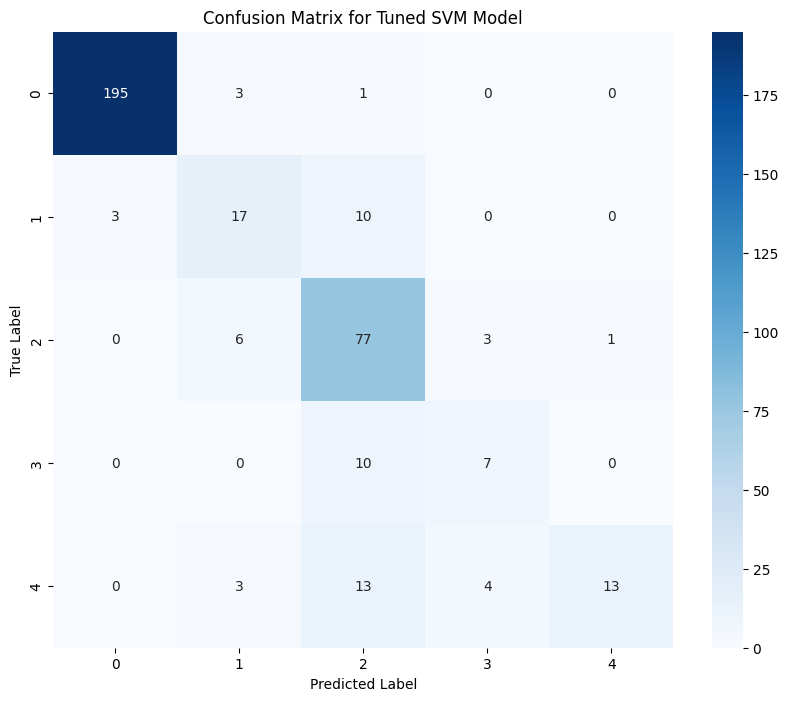

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test.argmax(axis=1), pred_tuned_svm), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Tuned SVM Model')
plt.savefig('/content/drive/MyDrive/EffnetB0SVM/confusion_matrix_tuned_svm.png')
plt.show()